# 10장. 회귀분석 (2) 대기 오염 데이터 분석

# 4. 데이터 준비 및 탐색

In [2]:
import numpy as np
import pandas as pd

In [3]:
data_df =  pd.read_csv('대기오염데이터_종로구_20220401_20240215.csv', header=0, encoding='CP949', engine='python')
data_df.head()   #작업 확인용 출력

,location,day,so2,co,o3,no2,pm10,pm25
0,종로구,2022-04-01,0.003,0.4,0.034,0.017,15,10
1,종로구,2022-04-02,0.004,0.4,0.036,0.022,30,19
2,종로구,2022-04-03,0.004,0.5,0.041,0.024,43,30
3,종로구,2022-04-04,0.004,0.6,0.040,0.029,57,41
4,종로구,2022-04-05,0.004,0.5,0.044,0.032,43,29


In [4]:
print(data_df.shape)

(673, 8)


In [5]:
data_df.isna().sum()

location    0
day         0
so2         7
co          0
o3          0
no2         0
pm10        0
pm25        0
dtype: int64

In [6]:
data_df = data_df.fillna(data_df['so2'].median())
data_df.isna().sum()  #작업 결과 확인

location    0
day         0
so2         0
co          0
o3          0
no2         0
pm10        0
pm25        0
dtype: int64

### 데이터 탐색을 위한 그래프 시각화

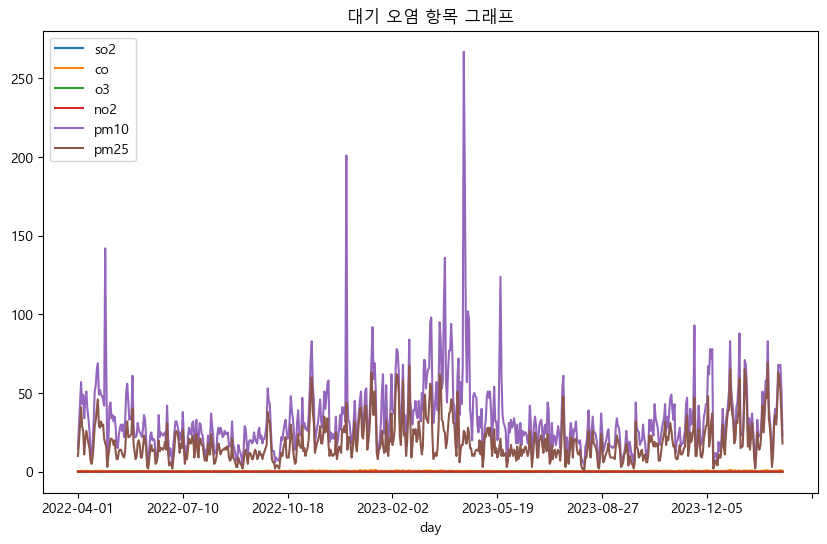

In [7]:
import matplotlib
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

graph_df = data_df.drop(['location'], axis = 1, inplace = False)
graph_df.set_index('day',inplace=True)
graph_df.plot(kind='line', figsize=(10, 6))  # kind='line'으로 선형 그래프 지정

plt.title('대기 오염 항목 그래프')  
plt.xlabel('day')  # x 축 레이블 설정
plt.legend(loc='upper left')  # 범례 위치 설정
plt.show()  

#### - 정규화하여 그래프 그리기 

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
data_df2 = data_df.drop(['location', 'day'], axis = 1, inplace = False)
data_df2_scaled = StandardScaler().fit_transform(data_df2.values)
data_df2 = pd.DataFrame(data_df2_scaled)
data_df2.columns = ['so2','co','o3','no2','pm10','pm25']

In [10]:
day_df = data_df[['day']].copy()
graph_df2 = pd.concat([day_df, data_df2], axis=1)

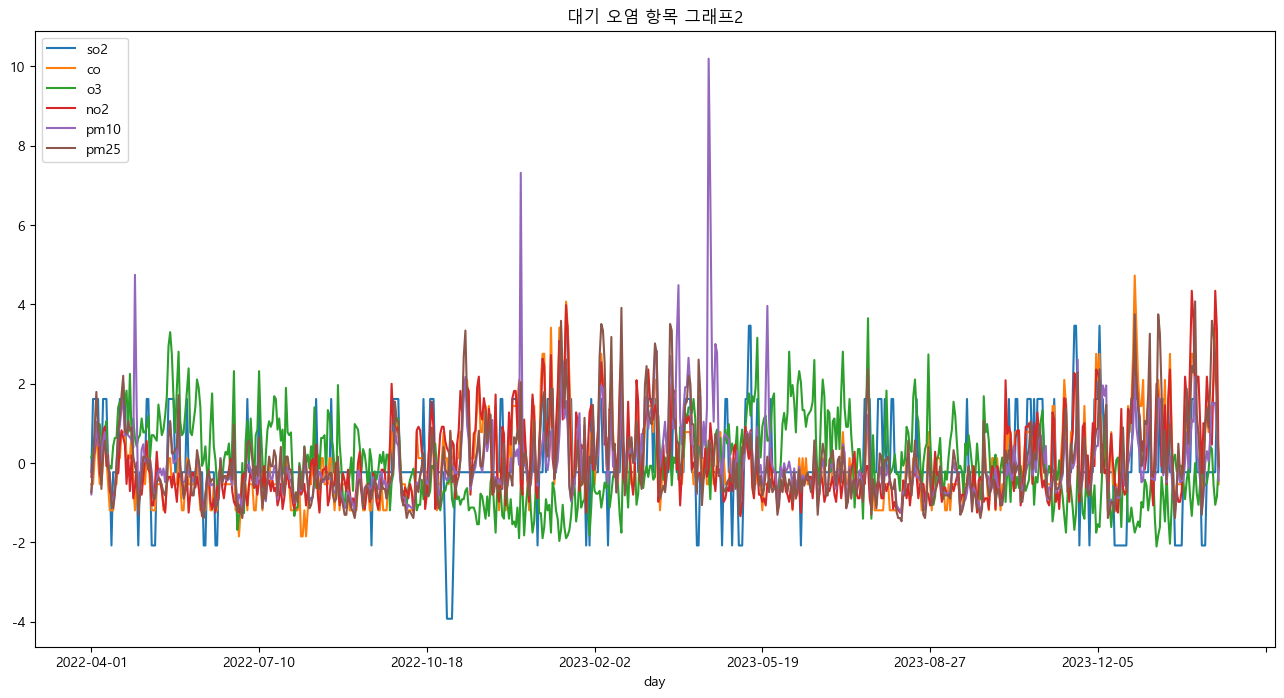

In [11]:
graph_df2.set_index('day',inplace=True)
graph_df2.plot(kind='line', figsize=(16, 8))  
plt.title('대기 오염 항목 그래프2')  
plt.xlabel('day')  
plt.legend(loc='upper left')  
plt.rcParams['axes.unicode_minus'] = False   #음수 부호 깨지지 않게 설정 
plt.show() 

# 5. 분석 모델 구축, 결과 분석 및 시각화

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# X, Y 분할하기
Y_pm10 = data_df['pm10']
Y_pm25 = data_df['pm25']
X = data_df.drop(['location', 'day','pm10', 'pm25'], axis=1, inplace=False)

## (1) 미세먼지 pm10 회귀 분석

### 회귀 분석 모델 구축

In [14]:
# 훈련용 데이터와 평가용 데이터 분할하기
X_train, X_test, Y_pm10_train, Y_pm10_test = train_test_split(X, Y_pm10, test_size=0.3, random_state=156)

In [15]:
# 선형회귀분석 : 모델 생성
lr_pm10 = LinearRegression()

In [16]:
# 선형회귀분석 : 모델 훈련
lr_pm10.fit(X_train, Y_pm10_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm10_predict = lr_pm10.predict(X_test)

###  결과 분석 - 모델 평가 

In [18]:
mse = mean_squared_error(Y_pm10_test, Y_pm10_predict)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('R^2(Variance score) : {0:.3f}'.format(r2_score(Y_pm10_test, Y_pm10_predict)))

MSE : 293.367, RMSE : 17.128
R^2(Variance score) : 0.344


In [19]:
print('Y_pm10 절편 값: ', lr_pm10.intercept_)
print('회귀 계수 값: ', np.round(lr_pm10.coef_, 1))

Y_pm10 절편 값:  -24.637204220135345
회귀 계수 값:  [2512.8   55.2  444.8  447.3]


In [20]:
coef = pd.Series(data = np.round(lr_pm10.coef_, 2), index=X.columns)
coef.sort_values(ascending = False)

so2    2512.75
no2     447.27
o3      444.80
co       55.18
dtype: float64

###  회귀 분석 결과를 산점도 + 선형 회귀 그래프로 시각화

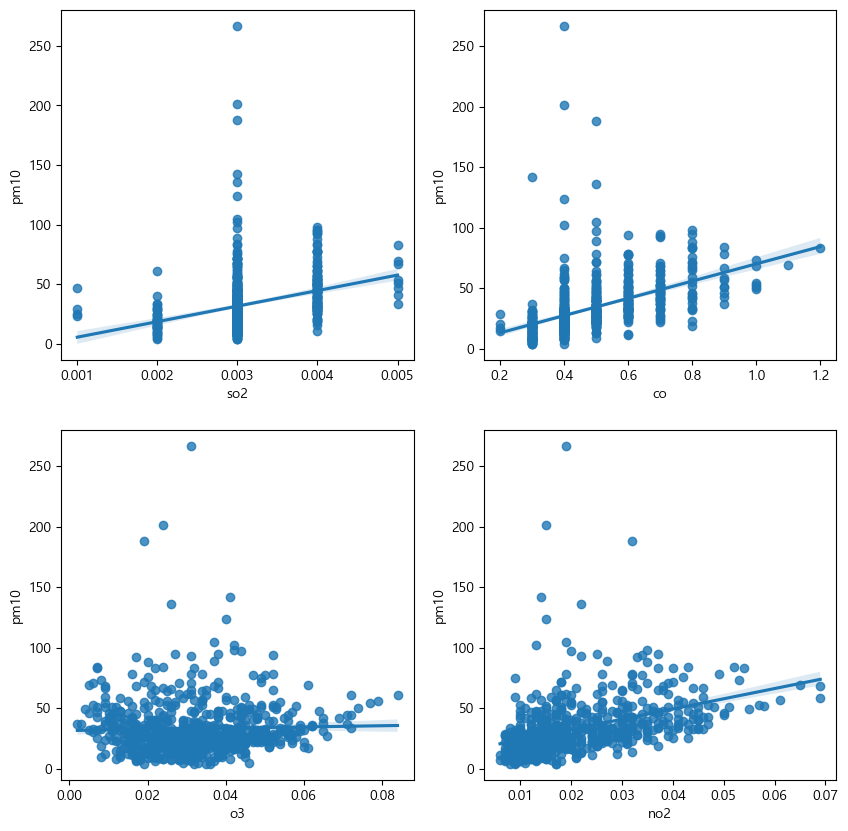

In [21]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
x_features = ['so2', 'co', 'o3', 'no2']

for i, feature in enumerate(x_features):
      row = int(i/2)
      col = i%2
      sns.regplot(x=feature, y='pm10', data=data_df, ax=axs[row][col])

## (2) 초세먼지 pm25 회귀 분석

### 회귀 분석 모델 구축

In [22]:
# 훈련용 데이터와 평가용 데이터 분할하기
X_train, X_test, Y_pm25_train, Y_pm25_test = train_test_split(X, Y_pm25, test_size=0.3, random_state=156)

In [24]:
# 선형회귀분석 : 모델 생성
lr_pm25 = LinearRegression()

In [25]:
# 선형회귀분석 : 모델 훈련
lr_pm25.fit(X_train, Y_pm25_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm25_predict = lr_pm25.predict(X_test)

###  결과 분석 - 모델 평가 

In [27]:
mse = mean_squared_error(Y_pm25_test, Y_pm25_predict)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('R^2(Variance score) : {0:.3f}'.format(r2_score(Y_pm25_test, Y_pm25_predict)))

MSE : 51.813, RMSE : 7.198
R^2(Variance score) : 0.661


In [28]:
print('Y_pm25 절편 값: ', lr_pm25.intercept_)
print('회귀 계수 값: ', np.round(lr_pm25.coef_, 1))

Y_pm25 절편 값:  -22.952459871175403
회귀 계수 값:  [776.   61.5 218.2 136.8]


In [29]:
coef = pd.Series(data = np.round(lr_pm25.coef_, 2), index=X.columns)
coef.sort_values(ascending = False)

so2    776.01
o3     218.18
no2    136.83
co      61.50
dtype: float64

### - 회귀 분석 결과를 산점도 + 선형 회귀 그래프로 시각화

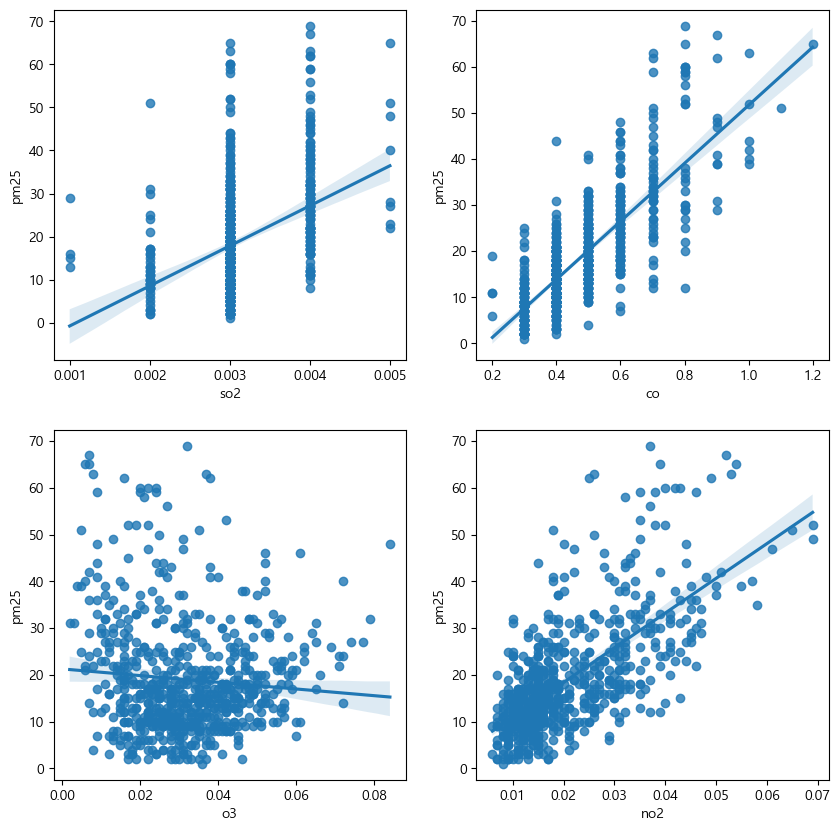

In [30]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
x_features = ['so2', 'co', 'o3', 'no2']

for i, feature in enumerate(x_features):
      row = int(i/2)
      col = i%2
      sns.regplot(x=feature, y='pm25', data=data_df, ax=axs[row][col])